### Linear Regression From Scratch

In [127]:
from sklearn.datasets import load_diabetes, make_regression
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

In [136]:
class LinearRegression:
    def __init__(self, learning_rate, epochs):
        self.learning_rate=learning_rate
        self.epochs = epochs
        self.w = None
        self.b = None

    def predict(self, X):
        return X @ self.w + self.b

    def fit(self,X,y):
        n, features = X.shape
        
        self.w = np.zeros(features) # weight initialisation
        self.b = 0
        
        for i in range(self.epochs):
            # step - 1: predict for given X
            y_pred = self.predict(X)
            
            # step - 2: gradients w.r.t w,b
            dw = -(1/n)*(X.T @ (y - y_pred))
            db = -(1/n)*(np.sum(y-y_pred))
            
            # step - 3: update w,b using gradients
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db
            
            # step - 4: calculate the mse for analysing the perfomance
            mse = (1/2)*np.mean((y-y_pred)**2)
            
            if (i%10)==0:
                print(f"MSE for {i}th iteration: {mse}")

In [137]:
X,y = make_regression(n_samples=600, n_features=1,noise=5,random_state=42)

X = pd.DataFrame(X)

In [138]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

lr = LinearRegression(0.05,200)
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
print(y_test.shape)
print("R2 score : ", r2_score(y_test,y_pred))

MSE for 0th iteration: 273.0057427775741
MSE for 10th iteration: 104.63260039316451
MSE for 20th iteration: 45.101445122983975
MSE for 30th iteration: 24.031969148170074
MSE for 40th iteration: 16.567368606864758
MSE for 50th iteration: 13.920042389730826
MSE for 60th iteration: 12.980188911812263
MSE for 70th iteration: 12.646172745997426
MSE for 80th iteration: 12.527341305861837
MSE for 90th iteration: 12.48502061783845
MSE for 100th iteration: 12.46993262232603
MSE for 110th iteration: 12.464547856013855
MSE for 120th iteration: 12.462624070151826
MSE for 130th iteration: 12.46193605456173
MSE for 140th iteration: 12.46168974133908
MSE for 150th iteration: 12.461601469860438
MSE for 160th iteration: 12.461569804036644
MSE for 170th iteration: 12.461558433195847
MSE for 180th iteration: 12.461554346063526
MSE for 190th iteration: 12.461552875575876
(120,)
R2 score :  0.9389121377273383


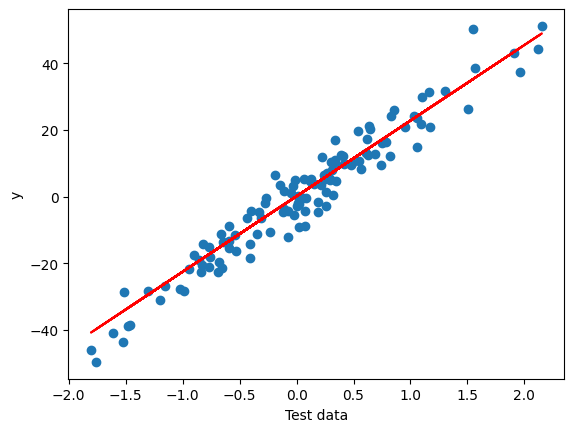

In [139]:
plt.xlabel('Test data')
plt.ylabel('y')
plt.scatter(X_test,y_test)
plt.plot(X_test, lr.predict(X_test), color='r')
plt.show()

## Using sklearn library

sklearn docs - https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

### Note
- sklearn module uses the ```closed form solution (linear algebra equation) ```under the hood. It is #not trained using iterative gradient descent method

- You can use ```SGDRegressor``` to train the regressor with Gradient style optimisation

In [140]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
print("R2 score : ", r2_score(y_test,y_pred))
print("Coefficient of determination R2: ", lr.score(X_test,y_test))

R2 score :  0.9389132734426341
Coefficient of determination R2:  0.9389132734426341


## SGDRegressor

sklearn docs - https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html

In [141]:
from sklearn.linear_model import SGDRegressor

model = SGDRegressor(
    learning_rate="constant",
    eta0=0.01,       # learning rate
    max_iter=10    # epochs / iterations
)

model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print("Coefficient of determination R2: ", model.score(X_test,y_test))

Coefficient of determination R2:  0.9380023555489287


/Users/sanvireddy/Desktop/Python/.venv/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
